# Hitmakers — Explainability Analysis (nb22)

SHAP waterfall analysis explaining individual predictions across all 6 models.

## Model provenance
All 6 models use feature sets and hyperparameters derived from the pipeline in nb21
(forward selection → Optuna re-tune → centrality ablation). CatBoost is the one
exception: while the pipeline produces a working CatBoost model, we were able to
push it further through dedicated regularization tuning — three Optuna runs with
Aggressive / Mid / Tight regularization constraints on n=12 features. The Mid
configuration achieved the best balance of CV AUC and overfit gap, outperforming
the pipeline version by ~0.017 Test AUC. All other models use pipeline params as-is.

## Analysis structure
- **False Positives**: artists the models call Hitmaker who turned out to be One-hit Wonders
- **True Positive reference**: a confirmed Hitmaker to contrast the FP profile
- **Key target artists**: auto-selected unanimous FPs + artists 235 (strongest FP) and 700 (most unanimous)

Note: AdaBoost models are excluded from SHAP waterfalls — their base estimators
are not supported by TreeExplainer. Permutation importance is used in the prediction table.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (AdaBoostClassifier, RandomForestClassifier)
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42

In [2]:
df = pd.read_csv('df_artists_final.csv', index_col=0).reset_index()

X = df.drop(columns=['top_20_hitmaker'])
y = df['top_20_hitmaker']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Impute — fit on train only
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns,  index=X_test.index)

# Genre consolidation — create artist_genre_other for models that need it.
# RF (pipeline): keeps Pop, Hip Hop/Rap, R&B/Soul/Funk, unknown individually.
# CatBoost: keeps Pop, Hip Hop/Rap, R&B/Soul/Funk, Rock individually.
# All other genre dummies → artist_genre_other (binary OR).
ALL_GENRE_COLS = [c for c in X_train_imp.columns if c.startswith('artist_genre_')]

def add_genre_other(df_imp, keep_genres):
    """Add artist_genre_other = 1 if any low-signal genre is 1."""
    keep_full = [f'artist_genre_{g}' if not g.startswith('artist_genre_') else g
                 for g in keep_genres]
    low_signal = [c for c in ALL_GENRE_COLS if c not in keep_full]
    df_imp = df_imp.copy()
    df_imp['artist_genre_other'] = (df_imp[low_signal].sum(axis=1) > 0).astype(int)
    return df_imp

# Create model-specific imputed datasets with artist_genre_other
# RF keeps: Pop, Hip Hop/Rap, R&B/Soul/Funk, unknown
X_train_rf = add_genre_other(X_train_imp,
    ['artist_genre_Pop', 'artist_genre_Hip Hop/Rap',
     'artist_genre_R&B/Soul/Funk', 'artist_genre_unknown'])
X_test_rf  = add_genre_other(X_test_imp,
    ['artist_genre_Pop', 'artist_genre_Hip Hop/Rap',
     'artist_genre_R&B/Soul/Funk', 'artist_genre_unknown'])

# CatBoost keeps: Pop, Hip Hop/Rap, R&B/Soul/Funk, Rock
X_train_catboost = add_genre_other(X_train_imp,
    ['artist_genre_Pop', 'artist_genre_Hip Hop/Rap',
     'artist_genre_R&B/Soul/Funk', 'artist_genre_Rock'])
X_test_catboost  = add_genre_other(X_test_imp,
    ['artist_genre_Pop', 'artist_genre_Hip Hop/Rap',
     'artist_genre_R&B/Soul/Funk', 'artist_genre_Rock'])

# Scaler for AdaBoost Linear only
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train_imp.columns, index=X_train_imp.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_imp),       columns=X_test_imp.columns,  index=X_test_imp.index)

print(f'Train: {X_train_imp.shape}, Test: {X_test_imp.shape}')
print(f'artist_genre_other created for RF and CatBoost')

Train: (607, 26), Test: (152, 26)
artist_genre_other created for RF and CatBoost nb18


In [3]:
# Hardcoded feature sets from nb21 pipeline (Steps 4-6).
# CatBoost uses a dedicated feature set from its own tuning (see intro).

FEATURES = {
    'AdaBoost Linear': [
        'eigenvector_centrality_top20_rolling5',
        'artist_genre_unknown',
        '#_of_charting_songs_through_first_top_20_hit',
        'artist_genre_Pop',
        'artist_genre_Hip Hop/Rap',
        'artist_genre_R&B/Soul/Funk',
        'top_20_hit_song_#_wks_on_chart_any_position',
        'betweenness_centrality_top20_rolling5',
        '#_of_genres_artist',
        'artist_genre_Folk',
        'years_through_first_top_20_hit',
    ],
    'AdaBoost Tree': [
        '#_of_charting_songs_through_first_top_20_hit',
        '#_of_genres_artist',
        'betweenness_centrality_top20_rolling5',
        'artist_genre_Pop',
        'harmonic_closeness_centrality_top20_rolling5',
    ],
    'Random Forest': [
        '#_of_charting_songs_through_first_top_20_hit',
        '#_of_genres_artist',
        'artist_genre_Hip Hop/Rap',
        'artist_genre_Pop',
        'artist_genre_unknown',
        'top_20_hit_song_#_wks_on_chart_any_position',
        'artist_genre_R&B/Soul/Funk',
        'years_through_first_top_20_hit',
        'artist_genre_other',
    ],
    'LightGBM': [
        '#_of_charting_songs_through_first_top_20_hit',
        'harmonic_closeness_centrality_top20_rolling5',
        '#_of_genres_artist',
        'years_through_first_top_20_hit',
        'artist_genre_Hip Hop/Rap',
        'artist_genre_Pop',
        'top_20_hit_song_#_wks_on_chart_any_position',
    ],
    'XGBoost': [
        '#_of_charting_songs_through_first_top_20_hit',
        '#_of_genres_artist',
        'artist_genre_Pop',
        'artist_genre_Hip Hop/Rap',
        'top_20_hit_song_#_wks_on_chart_any_position',
        'artist_genre_R&B/Soul/Funk',
        'artist_genre_unknown',
    ],
    # CatBoost dedicated feature set
    'CatBoost': [
        '#_of_charting_songs_through_first_top_20_hit',
        '#_of_genres_artist',
        'betweenness_centrality_top20_rolling5',
        'artist_genre_Pop',
        'harmonic_closeness_centrality_top20_rolling5',
        'eigenvector_centrality_top20_rolling5',
        'years_through_first_top_20_hit',
        'artist_genre_Hip Hop/Rap',
        'top_20_hit_song_#_wks_on_chart_any_position',
        'artist_genre_other',
        'artist_genre_R&B/Soul/Funk',
        'artist_genre_Rock',
    ],
}

MODEL_NAMES = list(FEATURES.keys())
print('Feature counts:', {k: len(v) for k, v in FEATURES.items()})

Feature counts: {'AdaBoost Linear': 11, 'AdaBoost Tree': 5, 'Random Forest': 9, 'LightGBM': 7, 'XGBoost': 7, 'CatBoost (nb18)': 12}


In [4]:
# Hardcoded best params from nb21 pipeline Step 5 re-tune (complexity table + Optuna output).
# CatBoost: Mid-regularization dedicated Optuna params (seed=42, 100 trials).

PARAMS = {
    'AdaBoost Linear': {
        'n_estimators': 257, 'learning_rate': 0.107,
        'alpha': 1e-05, 'penalty': 'l2', 'l1_ratio': 0.15,
    },
    'AdaBoost Tree': {
        'n_estimators': 130, 'learning_rate': 0.0158, 'max_depth': 2,
    },
    'Random Forest': {
        'n_estimators': 409, 'max_depth': 2, 'min_samples_leaf': 17, 'max_features': 'sqrt',
    },
    'LightGBM': {
        'n_estimators': 237, 'learning_rate': 0.005, 'max_depth': 9,
        'num_leaves': 41, 'reg_alpha': 0.0001, 'reg_lambda': 0.51, 'min_child_samples': 38,
    },
    'XGBoost': {
        'n_estimators': 239, 'learning_rate': 0.0238, 'max_depth': 5,
        'min_child_weight': 12, 'gamma': 4.5, 'subsample': 0.62,
        'colsample_bytree': 0.36, 'reg_alpha': 0.36, 'reg_lambda': 0.0,
    },
    # CatBoost Mid-regularization Optuna params (seed=42, 100 trials)
    'CatBoost': {
        'n_estimators': 50, 'learning_rate': 0.06180643097470682,
        'depth': 3, 'l2_leaf_reg': 4.970472180919757,
        'random_strength': 3.657777929321733, 'min_data_in_leaf': 9,
        'border_count': 178,
    },
}

In [5]:
def build_model(name, params):
    if name == 'AdaBoost Linear':
        base = SGDClassifier(
            loss='log_loss', alpha=params['alpha'],
            penalty=params['penalty'], l1_ratio=params['l1_ratio'],
            max_iter=1000, random_state=RANDOM_STATE,
        )
        return AdaBoostClassifier(
            estimator=base, n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'], random_state=RANDOM_STATE,
        )
    elif name == 'AdaBoost Tree':
        base = DecisionTreeClassifier(max_depth=params['max_depth'], random_state=RANDOM_STATE)
        return AdaBoostClassifier(
            estimator=base, n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'], random_state=RANDOM_STATE,
        )
    elif name == 'Random Forest':
        return RandomForestClassifier(
            n_estimators=params['n_estimators'], max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'], max_features=params['max_features'],
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
        )
    elif name == 'LightGBM':
        return LGBMClassifier(
            n_estimators=params['n_estimators'], learning_rate=params['learning_rate'],
            max_depth=params['max_depth'], num_leaves=params['num_leaves'],
            reg_alpha=params['reg_alpha'], reg_lambda=params['reg_lambda'],
            min_child_samples=params['min_child_samples'],
            random_state=RANDOM_STATE, verbose=-1, n_jobs=-1,
        )
    elif name == 'XGBoost':
        return XGBClassifier(
            n_estimators=params['n_estimators'], learning_rate=params['learning_rate'],
            max_depth=params['max_depth'], min_child_weight=params['min_child_weight'],
            gamma=params['gamma'], subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            reg_alpha=params['reg_alpha'], reg_lambda=params['reg_lambda'],
            random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0,
        )
    elif name == 'CatBoost':
        return CatBoostClassifier(
            n_estimators=params['n_estimators'], learning_rate=params['learning_rate'],
            depth=params['depth'], l2_leaf_reg=params['l2_leaf_reg'],
            random_strength=params['random_strength'],
            min_data_in_leaf=params['min_data_in_leaf'],
            border_count=params['border_count'],
            random_state=RANDOM_STATE, verbose=0,
        )

# Map model name to the correct base imputed dataset (for genre consolidation)
BASE_TRAIN = {
    'AdaBoost Linear':  X_train_scaled,  # scaled, no artist_genre_other needed
    'AdaBoost Tree':    X_train_imp,
    'Random Forest':    X_train_rf,      # has artist_genre_other (RF definition)
    'LightGBM':         X_train_imp,
    'XGBoost':          X_train_imp,
    'CatBoost':         X_train_catboost,
}
BASE_TEST = {
    'AdaBoost Linear':  X_test_scaled,
    'AdaBoost Tree':    X_test_imp,
    'Random Forest':    X_test_rf,
    'LightGBM':         X_test_imp,
    'XGBoost':          X_test_imp,
    'CatBoost':         X_test_catboost,
}

# Fit models
models = {}
X_train_final = {}
X_test_final  = {}

for name in MODEL_NAMES:
    feats = FEATURES[name]
    Xtr = BASE_TRAIN[name][feats]
    Xte = BASE_TEST[name][feats]
    X_train_final[name] = Xtr
    X_test_final[name]  = Xte
    m = build_model(name, PARAMS[name])
    m.fit(Xtr, y_train)
    models[name] = m
    auc = roc_auc_score(y_test, m.predict_proba(Xte)[:, 1])
    print(f'{name:<20}  Test AUC: {auc:.4f}')

AdaBoost Linear       Test AUC: 0.7465
AdaBoost Tree         Test AUC: 0.7432
Random Forest         Test AUC: 0.7671
LightGBM              Test AUC: 0.7518
XGBoost               Test AUC: 0.7717
CatBoost (nb18)       Test AUC: 0.7696


In [6]:
# Build prediction table and identify target artists.
# Thresholds from nb21 pipeline (OOF-tuned).
THRESHOLDS = {
    'AdaBoost Linear': 0.28,
    'AdaBoost Tree':   0.48,
    'Random Forest':   0.49,
    'LightGBM':        0.43,
    'XGBoost':         0.44,
    'CatBoost': 0.40,
}

probas = {name: models[name].predict_proba(X_test_final[name])[:, 1] for name in MODEL_NAMES}
preds  = {name: (probas[name] >= THRESHOLDS[name]).astype(int)          for name in MODEL_NAMES}

df_pred = pd.DataFrame(
    {name: probas[name].round(3) for name in MODEL_NAMES},
    index=y_test.index
)
df_pred['True Label'] = y_test.values
df_pred['True Class'] = y_test.map({0: 'One-hit Wonder', 1: 'Hitmaker'}).values
df_pred['N_Predict_Hitmaker'] = sum(preds[n] for n in MODEL_NAMES)
df_pred['Disagreement'] = df_pred[MODEL_NAMES].std(axis=1).round(3)

# Unanimous FPs: all 6 models predict hitmaker, true = 0
unanimous_fp = df_pred[(df_pred['N_Predict_Hitmaker'] == 6) & (df_pred['True Label'] == 0)]
near_fp      = df_pred[(df_pred['N_Predict_Hitmaker'] >= 5) & (df_pred['True Label'] == 0)]
unanimous_tp = df_pred[(df_pred['N_Predict_Hitmaker'] == 6) & (df_pred['True Label'] == 1)]
high_disagree = df_pred.sort_values('Disagreement', ascending=False).head(10)

print(f'Unanimous FPs (all 6 models): {len(unanimous_fp)}')
print(f'Near-unanimous FPs (5+/6):    {len(near_fp)}')
print(f'Unanimous TPs:                {len(unanimous_tp)}')

print('\n--- Unanimous / Near-unanimous FPs ---')
print(near_fp.to_string())

print('\n--- Unanimous TPs (sample) ---')
print(unanimous_tp.head(5).to_string())

print('\n--- Top 10 high-disagreement ---')
print(high_disagree[MODEL_NAMES + ['True Class', 'Disagreement']].to_string())

Unanimous FPs (all 6 models): 11
Near-unanimous FPs (5+/6):    21
Unanimous TPs:                36

--- Unanimous / Near-unanimous FPs ---
     AdaBoost Linear  AdaBoost Tree  Random Forest  LightGBM  XGBoost  CatBoost (nb18)  True Label      True Class  N_Predict_Hitmaker  Disagreement
158            0.849          0.684          0.575     0.410    0.598            0.558         0.0  One-hit Wonder                   5         0.146
146            0.155          0.676          0.535     0.431    0.450            0.445         0.0  One-hit Wonder                   5         0.171
656            0.151          0.622          0.617     0.453    0.526            0.435         0.0  One-hit Wonder                   5         0.174
605            0.126          0.622          0.557     0.514    0.450            0.429         0.0  One-hit Wonder                   5         0.174
583            0.407          0.622          0.621     0.407    0.530            0.512         0.0  One-hit Wonder  

## SHAP Waterfall Analysis

For tree models (Random Forest, LightGBM, XGBoost, CatBoost) we use `shap.TreeExplainer`.
For AdaBoost models we use permutation importance (TreeExplainer does not support
sklearn AdaBoostClassifier with SGDClassifier or stump base estimators).

SHAP waterfall = per-artist breakdown of how each feature pushed the prediction
above or below the baseline (average predicted probability across the test set).
Red bars push toward Hitmaker; blue bars push toward One-hit Wonder.

In [7]:
TREE_MODELS = ['Random Forest', 'LightGBM', 'XGBoost', 'CatBoost']

shap_explainers = {}
shap_values_test = {}  # shape: (n_test, n_features) for each model

for name in TREE_MODELS:
    explainer = shap.TreeExplainer(models[name])
    sv = explainer.shap_values(X_test_final[name])
    if isinstance(sv, list):   sv = sv[1]   # binary RF
    elif sv.ndim == 3:         sv = sv[:, :, 1]
    shap_explainers[name]   = explainer
    shap_values_test[name]  = sv
    print(f'{name}: SHAP computed, shape={sv.shape}')

Random Forest: SHAP computed, shape=(152, 9)
LightGBM: SHAP computed, shape=(152, 7)
XGBoost: SHAP computed, shape=(152, 7)
CatBoost (nb18): SHAP computed, shape=(152, 12)


In [8]:
def waterfall_for_artist(artist_idx, name, ax=None, title_suffix=''):
    """
    Draw a horizontal SHAP waterfall for one artist + one model.
    artist_idx: index in y_test (original df index).
    """
    feats   = FEATURES[name]
    X_te    = X_test_final[name]
    row_pos = list(X_te.index).index(artist_idx)  # position in test array

    if name in TREE_MODELS:
        sv       = shap_values_test[name][row_pos]
        base_val = shap_explainers[name].expected_value
        if isinstance(base_val, (list, np.ndarray)): base_val = base_val[1]
        sv_series = pd.Series(sv, index=feats)
    else:
        # AdaBoost: permutation importance * sign(mean direction) as proxy
        # Not per-artist, but shows model's general feature weights
        perm = permutation_importance(
            models[name], X_te, y_test, n_repeats=10,
            random_state=RANDOM_STATE, scoring='roc_auc'
        )
        sv_series = pd.Series(perm.importances_mean, index=feats)
        base_val  = probas[name].mean()

    sv_sorted = sv_series.sort_values(key=abs, ascending=True)
    colors    = ['#d73027' if v > 0 else '#4575b4' for v in sv_sorted]

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, max(4, len(feats) * 0.45)))

    bars = ax.barh(sv_sorted.index, sv_sorted.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)

    pred_prob  = probas[name][list(X_te.index).index(artist_idx)] if artist_idx in X_te.index else None
    true_label = y_test.loc[artist_idx]
    true_str   = 'Hitmaker' if true_label == 1 else 'One-hit Wonder'

    ax.set_title(
        f'{name}\nArtist {artist_idx} | True: {true_str} | P(Hitmaker)={pred_prob:.3f}{title_suffix}',
        fontsize=10
    )
    ax.set_xlabel('SHAP value (→ Hitmaker, ← One-hit Wonder)')
    return ax

In [9]:
# Choose target artists based on the prediction table above.
# Priority: unanimous FPs first, then near-unanimous FPs.

if len(unanimous_fp) > 0:
    fp_targets = list(unanimous_fp.index[:3])
    print('Unanimous FP targets:', fp_targets)
elif len(near_fp) > 0:
    fp_targets = list(near_fp.index[:3])
    print('Near-unanimous FP targets:', fp_targets)
else:
    # Fall back to highest disagreement one-hit wonders
    fp_targets = list(
        df_pred[df_pred['True Label'] == 0]
        .sort_values('Disagreement', ascending=False)
        .index[:3]
    )
    print('High-disagreement One-hit Wonder targets:', fp_targets)

tp_targets = list(unanimous_tp.index[:2]) if len(unanimous_tp) > 0 else []
print('TP targets:', tp_targets)

Unanimous FP targets: [732, 156, 333]
TP targets: [573, 107]


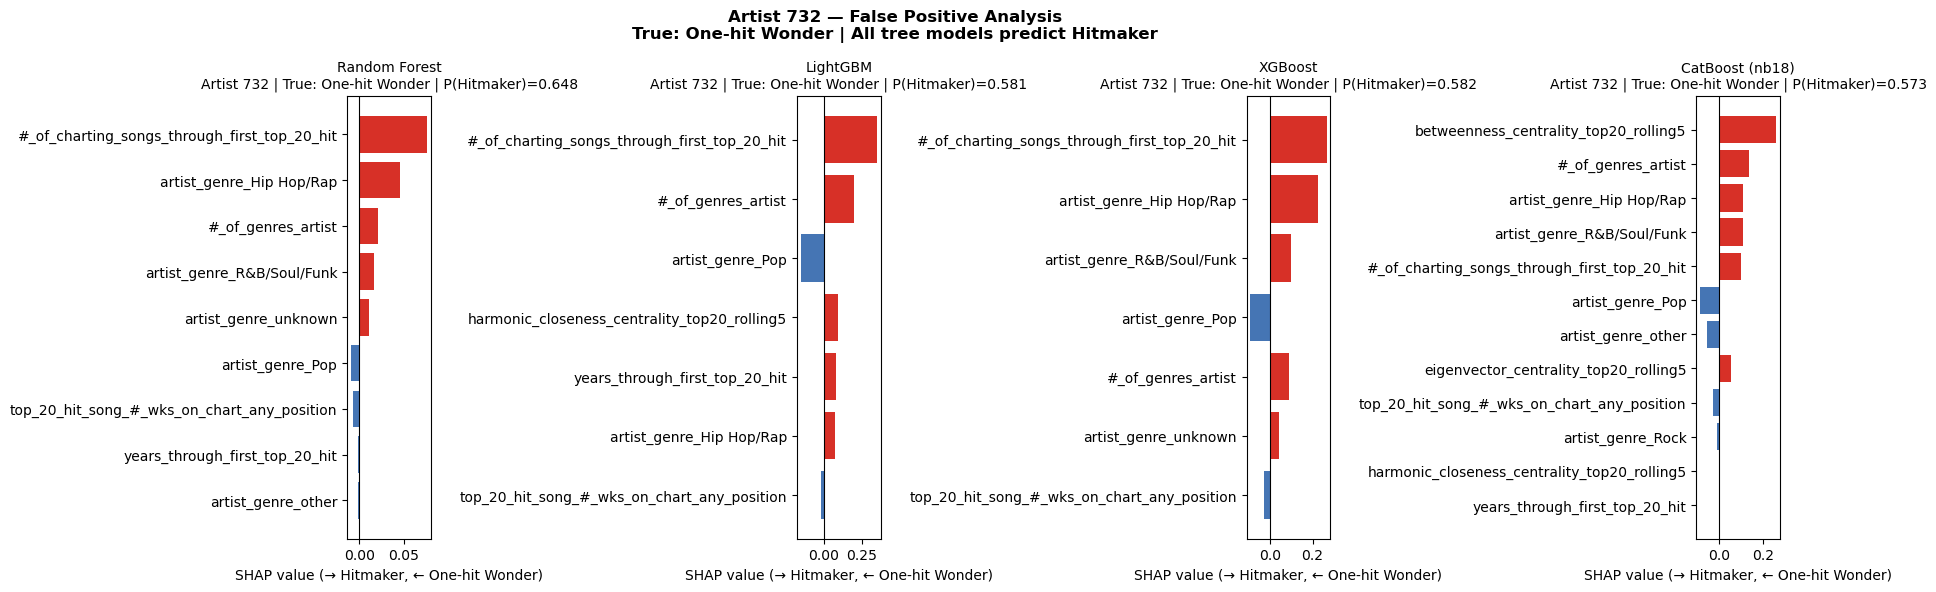

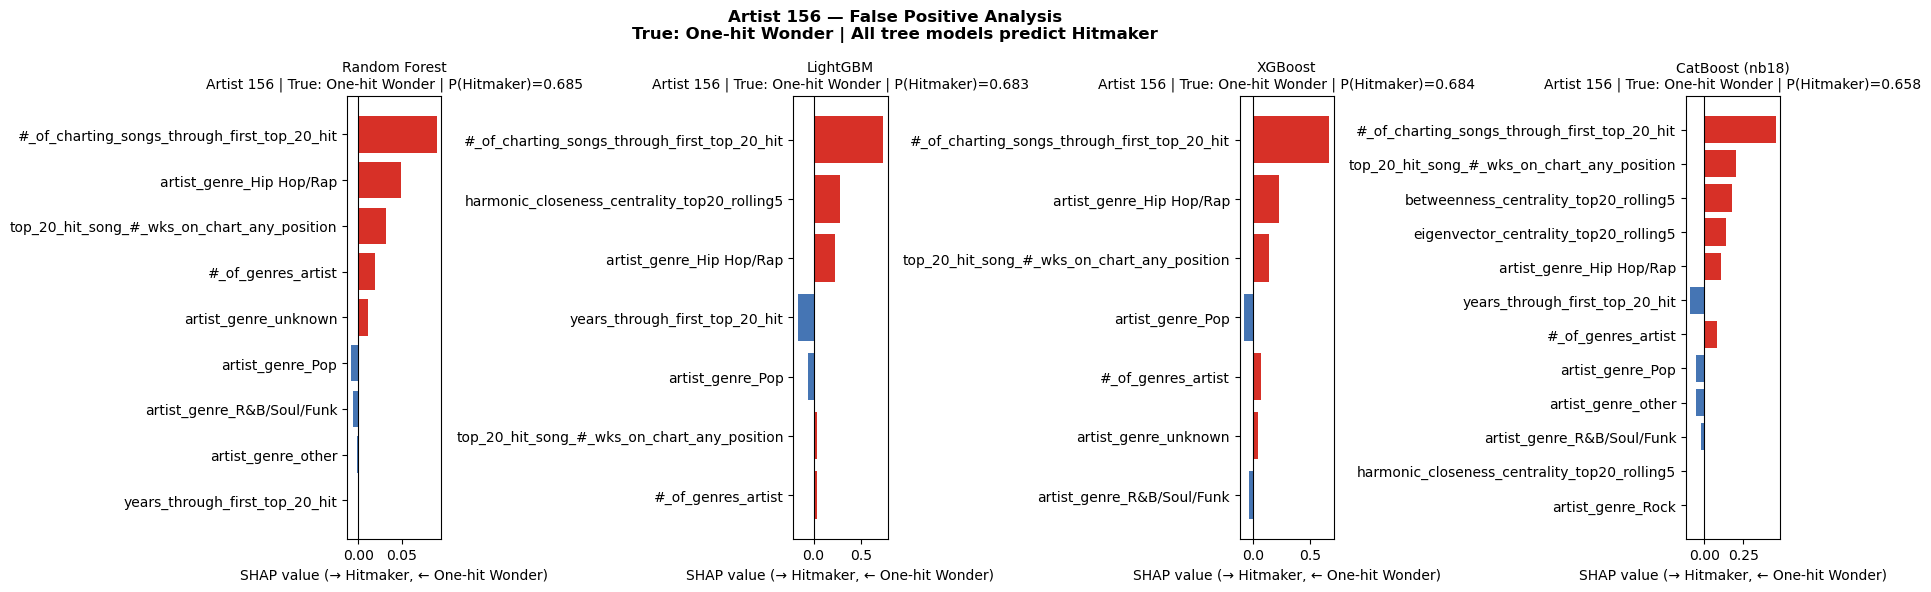

In [10]:
# SHAP waterfalls for false positive targets — tree models only.
# For each FP artist, show all 4 tree models side by side.

for artist_idx in fp_targets[:2]:
    fig, axes = plt.subplots(1, len(TREE_MODELS), figsize=(18, 6), sharey=False)
    fig.suptitle(
        f'Artist {artist_idx} — False Positive Analysis\n'
        f'True: One-hit Wonder | All tree models predict Hitmaker',
        fontsize=12, fontweight='bold'
    )
    for ax, name in zip(axes, TREE_MODELS):
        waterfall_for_artist(artist_idx, name, ax=ax)
    plt.tight_layout()
    plt.show()

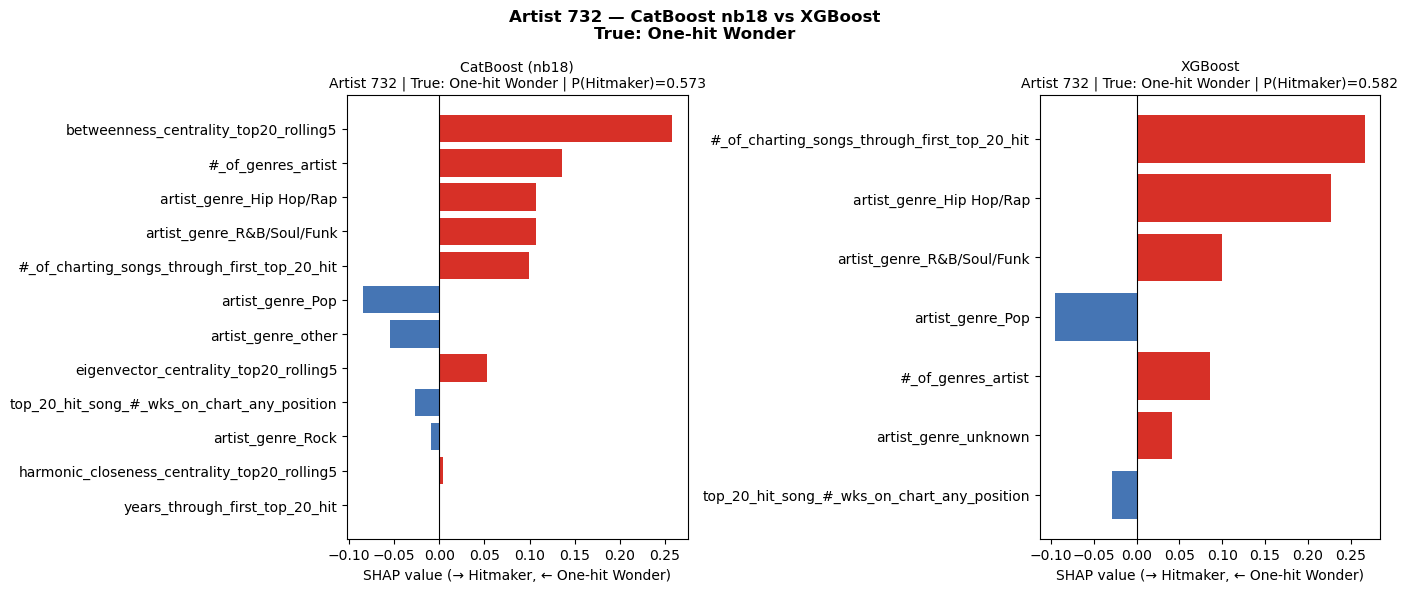

In [11]:
# CatBoost vs XGBoost direct comparison on the same FP artist.
# Most informative pair since they are closest in performance.

if fp_targets:
    artist_idx = fp_targets[0]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        f'Artist {artist_idx} — CatBoost vs XGBoost\n'
        f'True: One-hit Wonder',
        fontsize=12, fontweight='bold'
    )
    waterfall_for_artist(artist_idx, 'CatBoost',  ax=axes[0])
    waterfall_for_artist(artist_idx, 'XGBoost',         ax=axes[1])
    plt.tight_layout()
    plt.show()

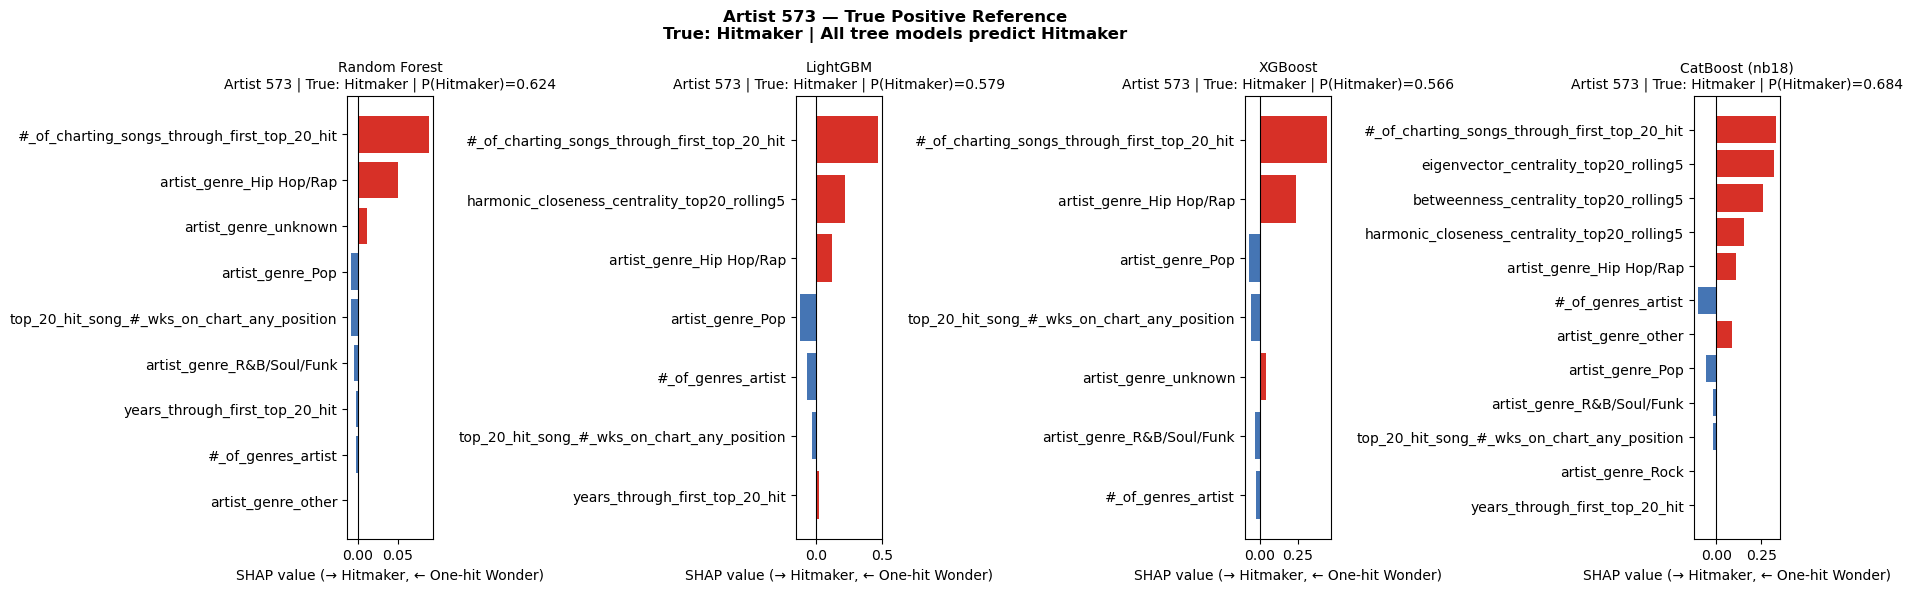

In [12]:
# Unanimous TP waterfall — reference case where all models agree correctly.
# Shows the 'textbook hitmaker' feature profile.

if tp_targets:
    artist_idx = tp_targets[0]
    fig, axes = plt.subplots(1, len(TREE_MODELS), figsize=(18, 6), sharey=False)
    fig.suptitle(
        f'Artist {artist_idx} — True Positive Reference\n'
        f'True: Hitmaker | All tree models predict Hitmaker',
        fontsize=12, fontweight='bold'
    )
    for ax, name in zip(axes, TREE_MODELS):
        waterfall_for_artist(artist_idx, name, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print('No unanimous TPs found — skipping TP reference plot.')

In [13]:
# SHAP contribution summary table for the primary FP artist.
# Shows which features pushed the prediction toward Hitmaker for each tree model.

if fp_targets:
    artist_idx = fp_targets[0]
    rows = []
    for name in TREE_MODELS:
        feats   = FEATURES[name]
        X_te    = X_test_final[name]
        row_pos = list(X_te.index).index(artist_idx)
        sv      = shap_values_test[name][row_pos]
        for feat, val in zip(feats, sv):
            rows.append({'Model': name, 'Feature': feat, 'SHAP': round(val, 4),
                         'Feature Value': round(X_te.iloc[row_pos][feat], 4)})

    df_shap = pd.DataFrame(rows)
    df_pivot = df_shap.pivot_table(index='Feature', columns='Model', values='SHAP', aggfunc='first')
    df_pivot = df_pivot.reindex(df_pivot.abs().max(axis=1).sort_values(ascending=False).index)
    print(f'SHAP contributions for artist {artist_idx} (sorted by max absolute SHAP):')
    print(df_pivot.round(4).to_string())

SHAP contributions for artist 732 (sorted by max absolute SHAP):
Model                                         CatBoost (nb18)  LightGBM  Random Forest  XGBoost
Feature                                                                                        
#_of_charting_songs_through_first_top_20_hit           0.0990    0.3508         0.0763   0.2661
betweenness_centrality_top20_rolling5                  0.2578       NaN            NaN      NaN
artist_genre_Hip Hop/Rap                               0.1072    0.0734         0.0453   0.2265
#_of_genres_artist                                     0.1363    0.2007         0.0206   0.0860
artist_genre_Pop                                      -0.0847   -0.1511        -0.0095  -0.0951
artist_genre_R&B/Soul/Funk                             0.1071       NaN         0.0159   0.0992
harmonic_closeness_centrality_top20_rolling5           0.0043    0.0937            NaN      NaN
years_through_first_top_20_hit                         0.0013    0.0831

### Artists 235 and 700 — Key False Positives

In [ ]:
# Artist 235 — strongest unanimous FP.
# All 6 models predict Hitmaker with high confidence (avg prob ~0.75).
artist_235 = 235
fig, axes = plt.subplots(1, len(TREE_MODELS), figsize=(18, 6), sharey=False)
fig.suptitle(
    'Artist 235 — Strongest Unanimous False Positive\n'
    'True: One-hit Wonder | All models predict Hitmaker with high confidence',
    fontsize=12, fontweight='bold'
)
for ax, name in zip(axes, TREE_MODELS):
    waterfall_for_artist(artist_235, name, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# Artist 700 — most unanimous FP (lowest disagreement = 0.045).
# Models agree more on this false alarm than almost any other artist.
artist_700 = 700
fig, axes = plt.subplots(1, len(TREE_MODELS), figsize=(18, 6), sharey=False)
fig.suptitle(
    'Artist 700 — Most Unanimous False Positive (lowest disagreement)\n'
    'True: One-hit Wonder | All models agree with high consistency',
    fontsize=12, fontweight='bold'
)
for ax, name in zip(axes, TREE_MODELS):
    waterfall_for_artist(artist_700, name, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# CatBoost vs XGBoost for artist 235 — strongest FP direct comparison.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Artist 235 — CatBoost vs XGBoost (strongest FP)\nTrue: One-hit Wonder',
    fontsize=12, fontweight='bold'
)
waterfall_for_artist(artist_235, 'CatBoost', ax=axes[0])
waterfall_for_artist(artist_235, 'XGBoost',  ax=axes[1])
plt.tight_layout()
plt.show()